D:\setup\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2570
Model:               ARIMA(12, 1, 12)   Log Likelihood                8514.024
Date:                Fri, 09 May 2025   AIC                         -16978.048
Time:                        23:37:43   BIC                         -16831.767
Sample:                             0   HQIC                        -16925.015
                               - 2570                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2814      1.160     -0.243      0.808      -2.555       1.993
ar.L2         -0.1163      1.282     -0.091      0.928      -2.628       2.396
ar.L3         -0.0820      0.796     -0.103      0.9

D:\setup\anaconda\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0195. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
D:\setup\anaconda\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0195. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
D:\setup\anaconda\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly sca

最优 GARCH 参数 (p, q): (1, 1)
Iteration:      1,   Func. Count:      6,   Neg. LLF: 680731332.2840034
Iteration:      2,   Func. Count:     21,   Neg. LLF: 36231073.30955809
Iteration:      3,   Func. Count:     34,   Neg. LLF: -5580.962094680896
Optimization terminated successfully    (Exit mode 0)
            Current function value: -5580.962183169104
            Iterations: 7
            Function evaluations: 34
            Gradient evaluations: 3
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                5580.96
Distribution:                  Normal   AIC:                          -11153.9
Method:            Maximum Likelihood   BIC:                          -11130.5
                                        No. Observations:                 

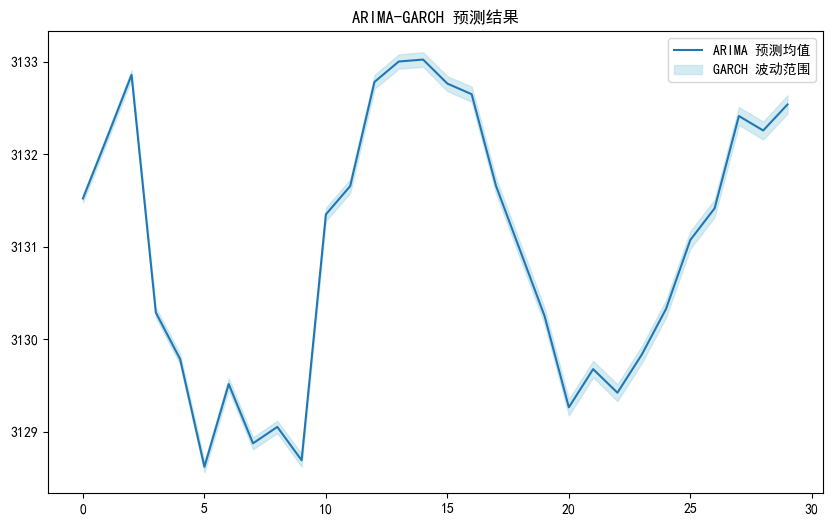

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from itertools import product

# 1. 加载数据
data = pd.read_csv("../data/huangjin_test.csv")
ts_data = data['deal_data'].values

# 对原始数据取对数
ts_data_log = np.log(ts_data)


arima_model = ARIMA(ts_data_log, order=(12,1,12))
arima_result = arima_model.fit()
print(arima_result.summary())

# 3. 提取 ARIMA 模型的残差
residuals = arima_result.resid

# 4. 自动选择 GARCH 参数并拟合 GARCH 模型
p_range = range(1, 4)
q_range = range(1, 4)
min_aic = np.inf
best_p, best_q = None, None

for p, q in product(p_range, q_range):
    try:
        garch_model = arch_model(residuals, vol="Garch", p=p, q=q)
        garch_result = garch_model.fit(disp="off")
        if garch_result.aic < min_aic:
            min_aic = garch_result.aic
            best_p, best_q = p, q
    except:
        continue

print(f"最优 GARCH 参数 (p, q): ({best_p}, {best_q})")

best_garch_model = arch_model(residuals, vol="Garch", p=best_p, q=best_q)
best_garch_result = best_garch_model.fit()
print(best_garch_result.summary())

# 5. 预测
# ARIMA 预测均值（对数尺度）
arima_forecast_log = arima_result.forecast(steps=30)

# 将对数尺度的预测值转换回原始尺度
arima_forecast = np.exp(arima_forecast_log)

# GARCH 预测条件方差
garch_forecast = best_garch_result.forecast(horizon=30)
garch_variance = garch_forecast.variance.iloc[-1].values


# 6. 将结果保存到 DataFrame
results_df = pd.DataFrame({
    "ARIMA 预测均值": arima_forecast,
    "GARCH 预测条件方差": garch_variance,
    "最终预测下限": arima_forecast - np.sqrt(garch_variance),
    "最终预测上限": arima_forecast + np.sqrt(garch_variance)
})

# 7. 保存到 Excel 文件
results_df.to_excel("../results/huangjin_forecast_new.xlsx", index=False)

print("预测结果已保存到 ../results/huangjin_forecast_new.xlsx")

# 8. 可视化结果
plt.figure(figsize=(10, 6))
plt.plot(arima_forecast, label="ARIMA 预测均值")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.fill_between(
    range(len(arima_forecast)),
    arima_forecast - np.sqrt(garch_variance),
    arima_forecast + np.sqrt(garch_variance),
    color="lightblue",
    alpha=0.5,
    label="GARCH 波动范围"
)
plt.title("ARIMA-GARCH 预测结果")
plt.legend()
plt.show()